
# Intensity Transformation for the Emma Watson Image



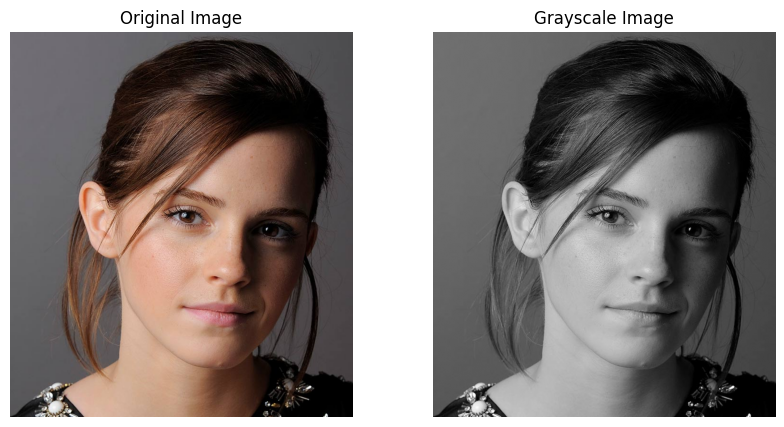

In [37]:
#import required libraries
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load image in color (BGR)
image_bgr = cv2.imread('emma.jpg')  

# Convert to grayscale
image_gray = cv2.imread('emma.jpg', cv2.IMREAD_GRAYSCALE)  

# Convert BGR to RGB 
image_rgb = cv2.cvtColor(image_bgr , cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image_rgb)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(image_gray, cmap='gray')
ax[1].set_title('Grayscale Image')
ax[1].axis('off')

plt.show()




 Define transformation function

In [8]:
#color image

def intensity_transform(input_intensity):
    if input_intensity < 50:
        return input_intensity  
    elif 50 <= input_intensity < 150:
        grad = (255-100) / (150 - 50)
        return int(100 + (input_intensity - 50) * grad)
    elif 150 <= input_intensity <= 255:
        grad = (255-150) / (255 - 150)
        return int(150 + (input_intensity - 150) * grad)
    else:
        return 255

In [ ]:
print(intensity_transform(200))  

200


Apply transformation to the image

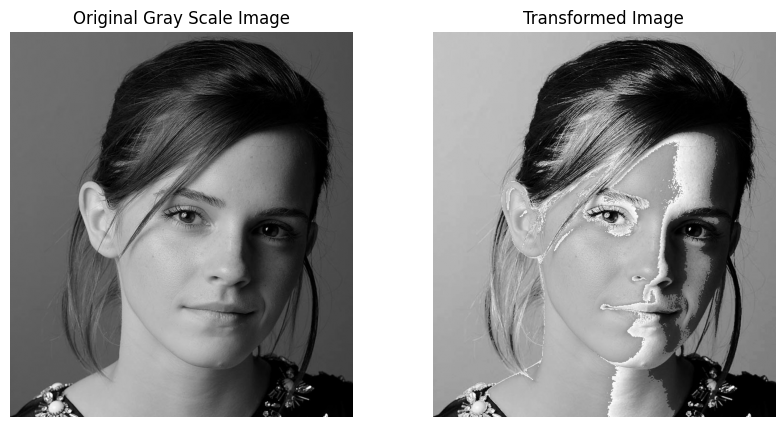

In [42]:
transformed_image = np.zeros_like(image_gray) # Output array

for i in range(image_gray.shape[0]):
    for j in range(image_gray.shape[1]):
        transformed_image[i, j] = intensity_transform(image_gray[i, j])
        


fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image_gray, cmap='gray')
ax[0].set_title('Original Gray Scale Image')
ax[0].axis('off')

ax[1].imshow(transformed_image, cmap='gray')
ax[1].set_title('Transformed Image')
ax[1].axis('off')

plt.show()


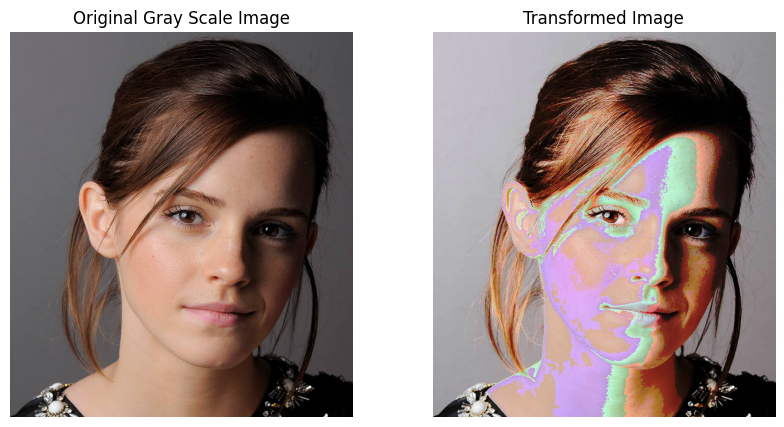

In [ ]:
transformed_original_image = np.zeros_like(image_rgb) # Output array

rows, cols, channels = image_rgb.shape # Get dimensions of the image(3 dimensional)

# Apply intensity transformation to each pixel
for i in range(rows):
    for j in range(cols):
        for c in range(channels):
            transformed_original_image[i, j, c] = intensity_transform(image_rgb[i, j, c])


fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image_rgb, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(transformed_original_image, cmap='gray')
ax[1].set_title('Transformed Image')
ax[1].axis('off')

plt.show()